In [1]:
import os
import numpy as np
import cv2
from PIL import Image
from matplotlib import pyplot as plt

In [2]:
pmatrix_new = np.load('./data/pmatrix_new.npy')
new_w = int(np.load('./data/new_w.npy'))
new_h = int(np.load('./data/new_h.npy'))

coord [80843700, 80851400, 80858100, 80864700, 80872600, 80881300, 80890500, 80899200, 80907700, 80919100, 80933800, 80949400, 80964800, 80977300, 80987000, 80995000, 81002100, 81009500, 81016600, 81023900, 81031300, 81038400, 81044800, 81050700, 81057100, 81063700, 81070000, 81077700, 81085300, 81092500, 81099100, 81105600, 81112600, 81120800, 81129400, 81138400, 81148100, 81157500, 81166100, 81173700, 81183100, 81194800, 81205100, 81215000, 81225500, 81236100, 81249800, 81260900, 81269900, 81278800, 81290100, 81300700, 81310300, 81321700, 81332500, 81341700, 81351300, 81361000, 81372400, 81382400, 81392700, 81405100, 81422100, 81441700, 81457100, 81470400, 81482200, 81492500, 81503200, 81512500, 81522800, 81535700, 81549800, 81562600, 81577500, 81590300, 81605400, 81619500, 81630300, 81640500, 81653400, 81667200, 81681500, 81692200, 81703900, 81718800, 81741700, 81761200, 81773100, 81782800, 81790300, 81797100, 81803200, 81808500]
(28522, 14268)


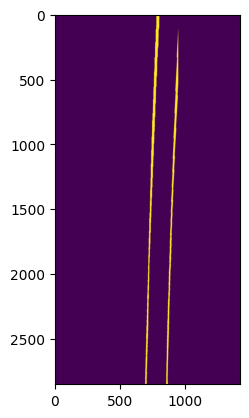

In [ ]:
src = r'./data/3/masks'
img_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.jpg')]
msk_fs = [os.path.join(src, f) for f in os.listdir(src) if f.endswith('.npy')]

import re
coord = []

msk_fs = msk_fs[:66]  # временно для тестов

for f in msk_fs:
    match = re.search(r'(\d+\.\d)', f)
    if match:
        result = match.group(1)
        coord.append(int(float(result)*1000))  # переводим координаты в мм

print('coord', coord)


def load_warp(mask_path):
    mask = np.load(mask_path)
    mask = np.array(mask, dtype=np.uint8)
    res = cv2.warpPerspective(mask, pmatrix_new, (new_w, new_h))
    res[:, :int(res.shape[1]/3)] = 0
    res[:, -int(res.shape[1]/3):] = 0
    return res

def resize(arr):
    # scale = 1000 / max(arr.shape)
    scale = 0.1
    display_res = cv2.resize(arr, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return display_res

# fig, ax = plt.subplots()

# # mask_pr = load_warp(r"D:\Projects\perspective\data\3\080843.789.jpg")
mask_pr = load_warp(msk_fs[20])

print(mask_pr.shape)
plt.imshow(resize(mask_pr))

In [5]:
def bend(mask, shift=200):
    h, w = mask.shape[:2]
    # Исходные углы (порядок: верх-лево, верх-право, низ-право, низ-лево)
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])

    dst = np.float32([
        [shift, 0],        # верх-лево → вправо
        [w + shift, 0],    # верх-право → влево
        [w, h],            # низ-право — на месте
        [0, h]             # низ-лево — на месте
    ])
    # Матрица и преобразование
    M = cv2.getPerspectiveTransform(src, dst)
    result = cv2.warpPerspective(mask, M, (w, h))
    return result

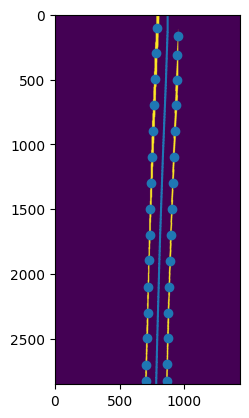

In [6]:
def find_rail_dots(mask, step=2000):
    # далее можно сократить расчеты
    """[Y, X] для рельсов, [y_centr, x_centr] для центр точек"""
    centroids = []

    height = mask.shape[0]
    num_steps = int(np.ceil(height / step))

    for i in range(num_steps):
        st = i * step
        en = np.min((st + step, height))
        contours, _ = cv2.findContours(mask[st:en, :], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        for contour in contours:
            M = cv2.moments(contour)
            if M["m00"] != 0:  # Проверяем, чтобы избежать деления на ноль
                cx = int(M["m10"] / M["m00"])
                cy = int(M["m01"] / M["m00"])
                centroids.append((cx, cy+st))

    X = np.array(centroids)[:, 0]
    Y = np.array(centroids)[:, 1]
    diff = np.diff(Y)
    # ищет пары близких центроидов (где вертикальное расстояние меньше 3 пикселей) и вычисляет для них среднюю точку по X

    mid_p = []
    for i, v in enumerate(diff):
        if v < 3:
            mid_x = int((X[i] + X[i+1]) / 2)
            mid_y = int((Y[i] + Y[i+1]) / 2)
            mid_p.append([mid_x, mid_y])

    mid_p = np.array(mid_p) # точки между центроидами
    # Интеролировать серединки для всех У
    y_centr = np.arange(mask.shape[0])
    x_centr = np.interp(y_centr, mid_p[:, 1], mid_p[:, 0])

    return np.array([Y, X]), np.array([y_centr, x_centr])


YX, yx_centr = find_rail_dots(mask_pr)

plt.imshow(resize(mask_pr))
plt.scatter(YX[1, :]//10, YX[0, :]//10)
plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
plt.margins(0, 0)


In [ ]:
# поворот

def rotate(rect, angle, point):
    """angle в радианах
       point точка вокруг которой повернуть
    """
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([
        [c, -s],
        [s,  c]
    ])

    shifted_rect = rect - point
    rotated_rectangle = (rotation_matrix @ shifted_rect.T).T + point
    return rotated_rectangle


-0.2074962264352027
-11.888658039627979


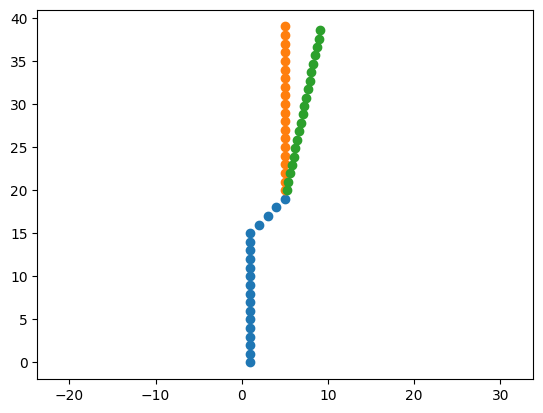

In [629]:

a1 = np.array([np.ones(20), np.arange(20)])
a1[0, 15:] += np.arange(5)



a2 = np.array([np.ones(20), np.arange(20, 40)])
a2[0, :] += 4

# p2 = a2.T[-1]
# p1 = a1.T[0]
# p3 =

b1 = [1, 19]
b0 = a1.T[0]
b = [5, 19]

# p2 = np.array([-5, 39])
# print(p1, p2)

# dx = p2[0] - p1[0]
# dy = p2[1] - p1[1]

# angle = np.arctan2(dx, dy)

angle = np.arctan2(b[1]-b0[1], b[0]-b0[0]) - np.arctan2(b1[1]-b0[1], b1[0]-b0[0])
angle_deg = np.degrees(angle)
print(angle)
print(angle_deg)

# нам нужен противоположный угол
# angle2 = np.pi / 2 - angle

# a3 = rotate(a2.T, angle, p2).T
a3 = rotate(a2.T, angle, a1.T[-1]).T  # повернуть на минус angle


plt.scatter(a1[0, :], a1[1, :])
plt.scatter(a2[0, :], a2[1, :])
plt.scatter(a3[0, :], a3[1, :])
plt.axis('equal');

In [602]:
a1.T[0]

array([1., 0.])

0.0704413866257277


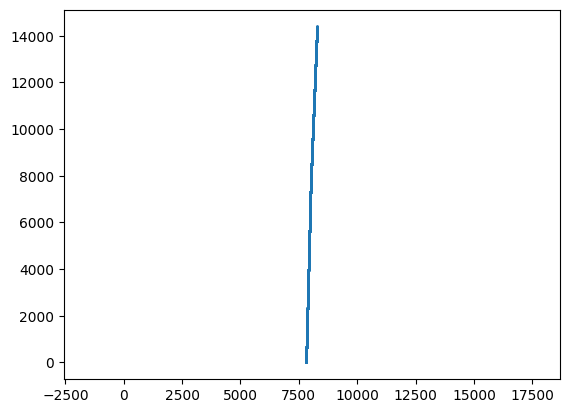

In [ ]:
# вариант с центр линией

"""yx_centr низ [-1], верх [0]"""

Array = np.zeros((1, 2))

niz_all = np.zeros((1))

x_norm = 7513. # (mask.shape[1] // 2) + 379

x_test = 0
coef = 0
shift = 0
for i, (m_f, c) in enumerate(zip(msk_fs[20:22], coord[20:22])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
    # plt.axvline((mask.shape[1] // 20)+38, c='g')
    # plt.show()

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    # для первой итерации
    if not coef:
        angle = 0
    else:
        # смещение по У
        yx_centr[:, 0] += coef
        niz_all = np.vstack((niz_all, yx_centr[-1, 1]))

        # поворот
        b = yx_centr[0][::-1] # xy
        a0 = [x_norm, yx_centr[-1, 0]]  # xy
        # print('b', np.int32(b),'a', np.int32(a0))

        dx = b[0] - a0[0]
        dy = b[1] - a0[1]
        _angle = np.arctan2(dx, dy)
        # if _angle > 0.029:
        angle += _angle  # накопить угол
        print(_angle)
        # print('dx', np.int32(dx), 'dy', np.int32(dy))
        # print('delta angle', _angle)
        yx_centr = rotate(yx_centr[:, [1, 0]], -angle / 5, yx_centr[-1, [1, 0]])[:, [1, 0]]
        # смещение по Х
        b0 = yx_centr[-1, 1]
        shift =  a - b0
        yx_centr[:, 1] += shift

    # для смещения по Х
    a = yx_centr[0, 1]


    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота
    # print('пройденное', np.int32(coef))



    Array = np.vstack((Array, yx_centr))
Array = Array[1:, :]  # убир перв строка, кот 0 0


plt.scatter(Array[:, 1], Array[:, 0], s=1)
plt.axis('equal')
plt.show()


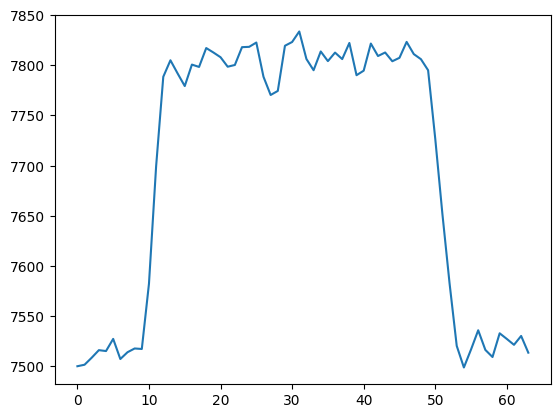

In [553]:
plt.plot(niz_all[1:])

In [510]:
_angle = np.arctan2(dx, dy)
_angle

np.float64(-0.0009024036635135606)

In [ ]:
p1, p2 = yx_centr[-1][::-1], yx_centr[0][::-1]
p1, p2
# 2. Расчет направляющего вектора линии
v = p2 - p1
# 3. Нахождение перпендикулярного вектора (поворот на 90 градусов)
# Для вектора (x, y) перпендикуляр равен (-y, x)
v_perp = np.array([-v[1], v[0]])
length = 3000.0
v_perp_normalized = v_perp / np.linalg.norm(v_perp) * length
p3 = p2 + v_perp_normalized
p4 = p2 - v_perp_normalized

plt.scatter(Array[:, 1], Array[:, 0])
plt.plot([p3[0], p4[0]], [p3[1], p4[1]], "r-o")
plt.axis('equal')
plt.show()

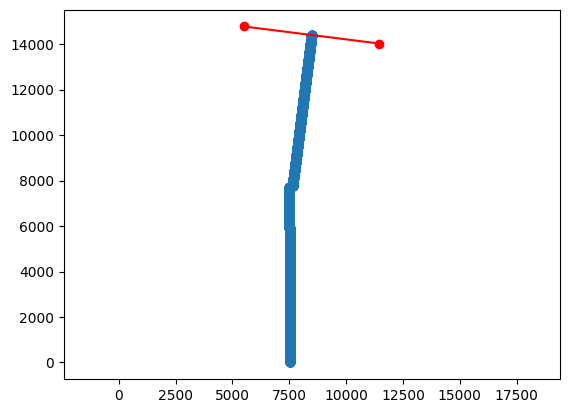

In [114]:
p3, p4

(array([ 5505.36911133, 14774.44378116]),
 array([11458.19767166, 14023.55621884]))

In [119]:
# угол от перп
dx_2 = p3[0] - p4[0]
dy_2 = p3[1] - p4[1]
angle_2 = np.arctan2(dx, dy)
print(angle_2)
np.degrees(angle_2)


0.12821503533142425


np.float64(7.346180394611344)

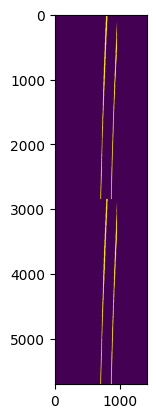

In [ ]:
# 05.06 заново
"""yx_centr низ [-1], верх [0]"""


Array = np.zeros((1, 1427))
# Array = np.zeros((1, 2))

coef = 0
shift = 0
for i, (m_f, c) in enumerate(zip(msk_fs[20:22], coord[20:22])):  # 0:-1 0:2 13:14 20:24 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
    # plt.axvline((mask.shape[1] // 20) + 38, c='g')
    # plt.show()

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    # ===========================================
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================

    # смещение по У
    yx_centr[:, 0] += coef
    if i == 0:
        pass
    else:



        # смещение по Х
        # сдвинуть центр в точку, где она находилась в предыдущ кадре
        a1 = yx_centr[-1][::-1]  # xy
        shift = b0[0] - a1[0]
        yx_centr[:, 1] += shift


    b0 = yx_centr[0][::-1]  # xy

    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота

    # plt.scatter(yx_centr[:, 1], yx_centr[:, 0], s=1)
    # plt.axis('equal')


    # Array = np.vstack((Array, yx_centr))
    Array = np.vstack((Array, resize(mask)))
Array = Array[1:, :]
plt.imshow(Array)

# plt.scatter(Array[:, 1], Array[:, 0], s=1)
# plt.axis('equal')
# plt.show()

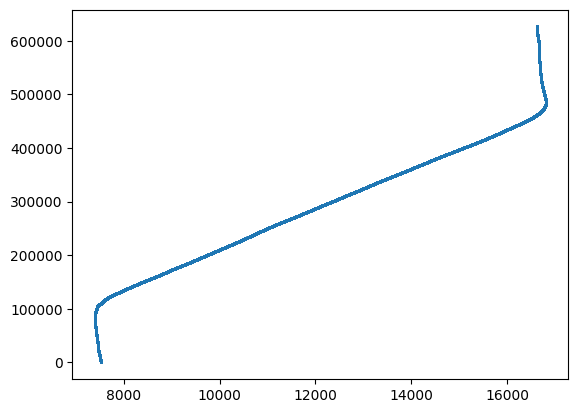

In [496]:
plt.scatter(Array[:, 1], Array[:, 0], s=1)


In [461]:
np.int32(yx_centr)

array([[7699, 8008],
       [7698, 8007],
       [7697, 8008],
       ...,
       [   2, 7823],
       [   1, 7823],
       [   0, 7823]], dtype=int32)

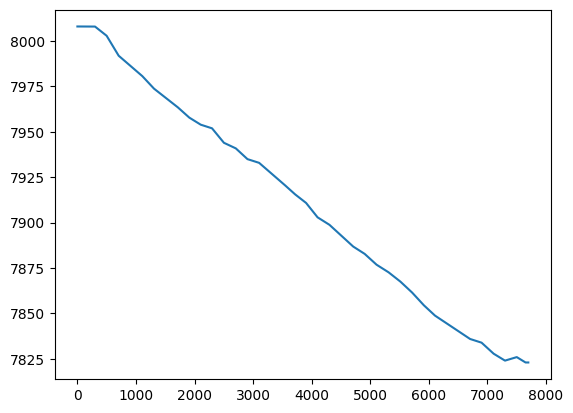

In [468]:
plt.plot(yx_centr[:, 1])

In [479]:
np.int32(yx_centr)

array([[7699, 8009],
       [7698, 8009],
       [7697, 8009],
       ...,
       [   2, 7812],
       [   1, 7812],
       [   0, 7812]], dtype=int32)

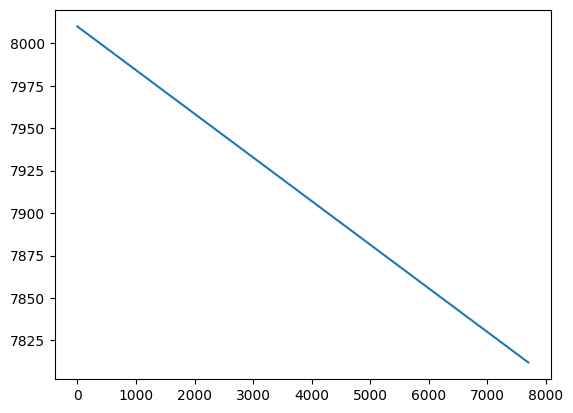

In [478]:
plt.plot(yx_centr[:, 1])


In [474]:
x_lin

array([1.000e+00, 8.008e+03])

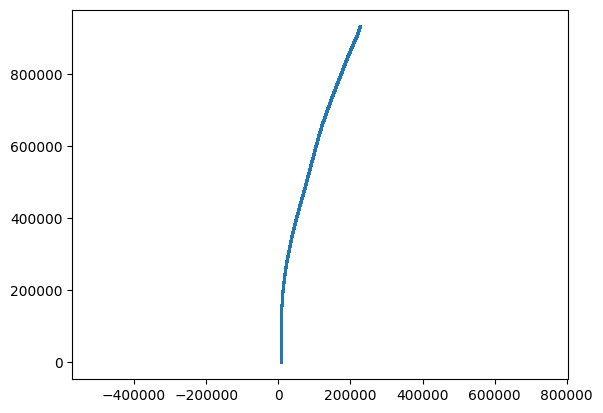

In [ ]:
# вариант с центр линией

"""yx_centr низ [-1], верх [0]"""
Array = np.zeros((1, 2))

niz_all = np.zeros((1, 1))
verx_all = np.zeros((1, 1))

x_norm = 7513. # (mask.shape[1] // 2) + 379

x_test = 0

angle = 0
coef = 0
shift = 0
for i, (m_f, c) in enumerate(zip(msk_fs[0:-1], coord[0:-1])):  # 0:-1 0:2 13:14 20:22 20:32 29:32
    mask = load_warp(m_f)
    mask = mask[mask.shape[0]-(coord[i+1] - coord[i]): mask.shape[0]+1]  # низ маски. низ - текущ коорд, верх след коорд (включительно)

    # mask = bend(mask, shift=2000)  # !! для теста
    _, yx_centr = find_rail_dots(mask, step=200)
    # plt.imshow(resize(mask))
    # plt.plot(yx_centr[1, :]//10, yx_centr[0, :]//10)
    # plt.axvline((mask.shape[1] // 20)+38, c='g')
    # plt.show()

    # преобразовать ось Y (переворот). Т.к.координаты на маске от нуля вверху,
    # реальные - от нуля внизу, и едем вперед
    yx_centr = yx_centr.T
    _y = yx_centr[:, 0]
    _y = _y[::-1]
    yx_centr[:, 0] = _y
    # ===========================================
    # лин регрессия
    kb = np.polyfit(yx_centr[:, 0], yx_centr[:, 1], 1)
    f = np.poly1d(kb)
    y_n = np.arange(yx_centr.shape[0])
    x_lin = f(yx_centr[:, 0])
    yx_centr[:, 1] = x_lin
    # ===========================================
    # для первой итерации
    if i == 0:
        pass
    else:
        # смещение по У
        yx_centr[:, 0] += coef

        # поворот
        b0 = yx_centr[-1][::-1]  # xy
        _b0 = [b0[0], yx_centr[0, 0]]  # проекция b0 на верхн грани
        b = yx_centr[0][::-1]  # xy

        _angle = np.arctan2(b[1]-b0[1], b[0]-b0[0]) - np.arctan2(_b0[1]-b0[1], _b0[0]-b0[0])
        angle += _angle  # накопить угол
        # print(_angle)
        # print(np.degrees(_angle))

        yx_centr = rotate(yx_centr[:, [1, 0]], angle, yx_centr[-1, [1, 0]])[:, [1, 0]]

        # смещение по Х
        # сдвинуть центр в точку, где она находилась в предыдущ кадре

        shift = a - yx_centr[-1, 1]
        yx_centr[:, 1] += shift

        # # отклон по Х от изгиба рельсы
        # shift =  a - b0
        # yx_centr[:, 1] += shift

    # обновл коорд Y на пройденный путь
    coef += yx_centr[0, 0] - yx_centr[-1, 0]  # shape тут не подходит, т.к. не измен после поворота

    # для смещения по Х
    a = yx_centr[0, 1]



    # print('пройденное', np.int32(coef))

    Array = np.vstack((Array, yx_centr))
Array = Array[1:, :]  # убир перв строка, кот 0 0

plt.scatter(Array[:, 1], Array[:, 0], s=1)
plt.axis('equal')
plt.show()


In [662]:
shift

array([-310.87078828, -201.99744984])